# Notebook 01 — Exploratory Data Analysis

**Repository:** `kubernetes/kubernetes`  
**Member:** Muhammad Asrofi Syaikho — Data Engineer 

---

Notebook ini berfokus pada pembersihan data mentah hasil *scraping* GitHub API dan menyajikan visualisasi tren volume issue serta status penyelesaian Pull Request. Output dari notebook ini akan menghasilkan berkas data bersih di folder `data/clean/` untuk digunakan pada tahapan analisis selanjutnya.

---
### AI Disclosure

**Member:** Muhammad Asrofi Syaikho — Data Engineer | **Tools used:** Claude

| Tugas | Alat | Prompt (Ringkasan) | Pemanfaatan Output |
|------|------|-------------------|---------------------|
| Penyesuaian struktur code EDA | Claude | "Generate saya code EDA mengikuti objektif yang telah diberikan" | Digunakan sebagai kerangka kode dan pemrosesan data. |

**Written entirely without AI:** Sel Interpretasi

---
## 0. Setup Lingkungan Pengembangan

In [1]:
import os
import glob
import warnings
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

RAW_DIR   = os.path.join("..", "data", "raw")
CLEAN_DIR = os.path.join("..", "data", "clean")
REPORT_DIR = os.path.join("..", "report")

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

---
## 1. Memuat Data Mentah (Raw Data)

Memuat berkas CSV terbaru hasil ekstraksi dari GitHub API untuk dataset issues dan pull requests.

In [2]:
def load_latest_dataset(pattern: str, date_cols: list) -> pd.DataFrame:
    files = glob.glob(os.path.join(RAW_DIR, f"{pattern}*.csv"))
    if not files:
        raise FileNotFoundError(f"Berkas dengan pola '{pattern}*.csv' tidak ditemukan di {RAW_DIR}.")
    latest_file = max(files, key=os.path.getmtime)
    df = pd.read_csv(latest_file, parse_dates=date_cols)
    print(f"Berhasil memuat: {latest_file}")
    print(f"Dimensi        : {df.shape[0]:,} baris x {df.shape[1]} kolom\n")
    return df

df_issues_raw = load_latest_dataset("dataset_issues_raw", date_cols=["created_at", "closed_at"])
df_prs_raw = load_latest_dataset("dataset_prs_raw", date_cols=["created_at", "closed_at", "merged_at"])

Berhasil memuat: ..\data\raw\dataset_issues_raw.csv
Dimensi        : 1,213 baris x 34 kolom

Berhasil memuat: ..\data\raw\dataset_prs_raw.csv
Dimensi        : 5,000 baris x 36 kolom



---
## 2. Pembersihan Data & Rekayasa Fitur

Tahap ini melakukan penghapusan duplikasi, standardisasi zona waktu ke UTC, serta ekstraksi komponen waktu (Tahun-Bulan) untuk keperluan agregasi tren bulanan.

In [3]:
def clean_issues_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Hapus duplikasi berdasarkan ID unik
    df.drop_duplicates(subset="id", keep="first", inplace=True)
    df.dropna(subset=["number", "created_at"], inplace=True)
    
    # Standardisasi zona waktu ke UTC
    for col in ["created_at", "closed_at"]:
        if df[col].dt.tz is None:
            df[col] = df[col].dt.tz_localize("UTC")
        else:
            df[col] = df[col].dt.tz_convert("UTC")
            
    # Ekstraksi fitur Periode (Tahun-Bulan)
    df["year_month"] = df["created_at"].dt.to_period("M").astype(str)
    return df

df_issues = clean_issues_data(df_issues_raw)
print(f"Issues Bersih: {len(df_issues):,} baris terproses.")

Issues Bersih: 1,213 baris terproses.


In [4]:
def clean_prs_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Hapus duplikasi berdasarkan ID unik
    df.drop_duplicates(subset="id", keep="first", inplace=True)
    df.dropna(subset=["number", "created_at"], inplace=True)
    
    # Standardisasi zona waktu ke UTC
    for col in ["created_at", "closed_at", "merged_at"]:
        if col in df.columns:
            if df[col].dt.tz is None:
                df[col] = df[col].dt.tz_localize("UTC")
            else:
                df[col] = df[col].dt.tz_convert("UTC")
                
    # Rekayasa fitur status Merge (1 jika berhasil di-merge, 0 jika closed tanpa merge/open)
    if "merged_at" in df.columns:
        df["is_merged"] = df["merged_at"].notna().astype(int)
    else:
        # Fallback jika kolom tidak ada
        df["is_merged"] = 0
        
    df["status_merge"] = df["is_merged"].map({1: "Merged", 0: "Not Merged"})
    df["year_month"] = df["created_at"].dt.to_period("M").astype(str)
    return df

df_prs = clean_prs_data(df_prs_raw)
print(f"PRs Bersih: {len(df_prs):,} baris terproses.")

PRs Bersih: 5,000 baris terproses.


---
## 3. Analisis Data Eksploratif (EDA)

### 3.1 Visualisasi Jumlah Issue per Bulan
Bagian ini menampilkan tren volume pembuatan issue baru di repositori dari waktu ke waktu untuk melihat stabilitas aktivitas atau lonjakan laporan tertentu.

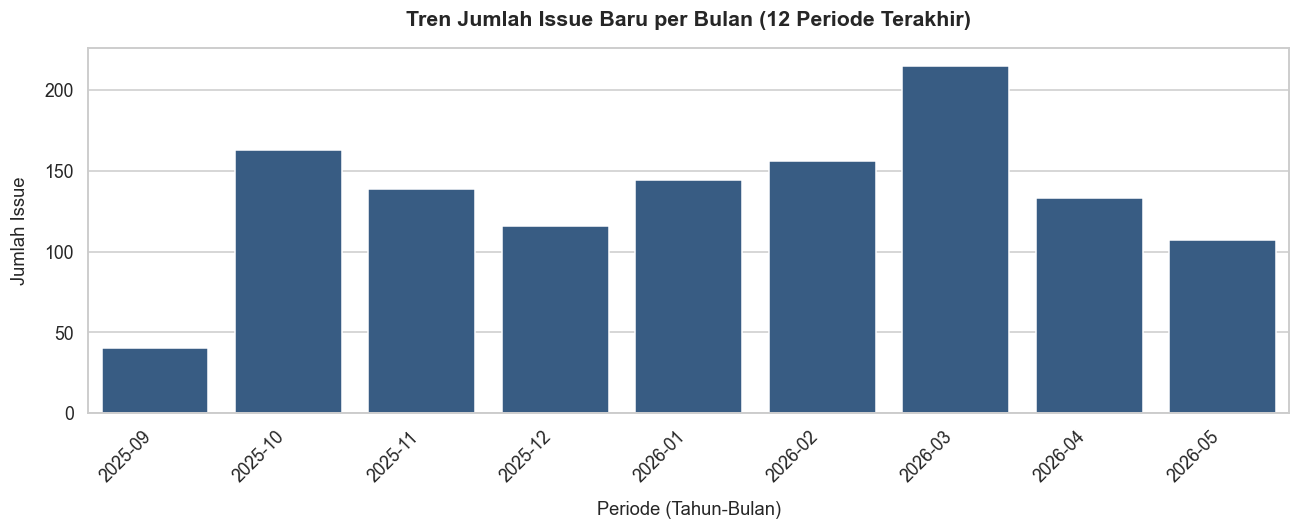

In [5]:
# Agregasi jumlah issue berdasarkan Tahun-Bulan
issues_trend = df_issues.groupby("year_month").size().reset_index(name="jumlah_issue").sort_values("year_month")

# Mengambil 12 periode bulanan terakhir agar visualisasi tetap rapi dan terbaca
issues_trend_plot = issues_trend.tail(12)

plt.figure(figsize=(12, 5))
sns.barplot(data=issues_trend_plot, x="year_month", y="jumlah_issue", color="#2b5c8f")
plt.title("Tren Jumlah Issue Baru per Bulan (12 Periode Terakhir)", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Periode (Tahun-Bulan)", fontsize=12, labelpad=10)
plt.ylabel("Jumlah Issue", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### 3.2 Visualisasi Jumlah Pull Request per Bulan
Bagian ini menampilkan tren volume pembuatan Pull request baru di repositori dari waktu ke waktu untuk melihat stabilitas aktivitas atau lonjakan laporan tertentu.

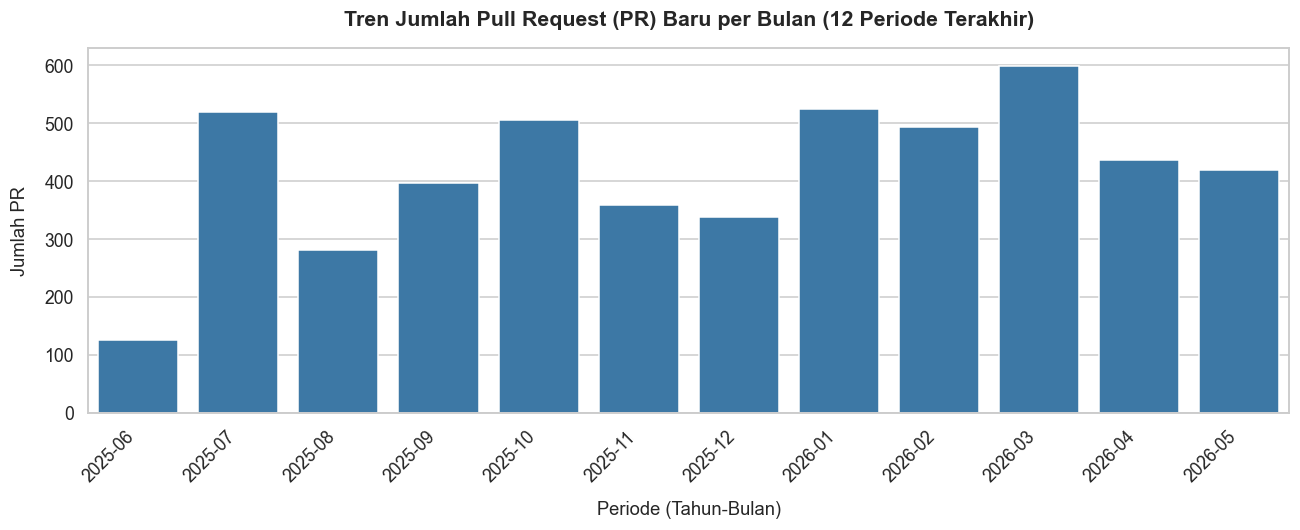

In [6]:
# Agregasi jumlah PR berdasarkan Tahun-Bulan
prs_trend = df_prs.groupby("year_month").size().reset_index(name="jumlah_pr").sort_values("year_month")

# Mengambil 12 periode bulanan terakhir
prs_trend_plot = prs_trend.tail(12)

plt.figure(figsize=(12, 5))
sns.barplot(data=prs_trend_plot, x="year_month", y="jumlah_pr", color="#2c7bb6")
plt.title("Tren Jumlah Pull Request (PR) Baru per Bulan (12 Periode Terakhir)", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Periode (Tahun-Bulan)", fontsize=12, labelpad=10)
plt.ylabel("Jumlah PR", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

**Interpretasi Grafik Tren Issue Bulanan:** *(Tuliskan analisis atau pengamatan Anda mengenai grafik di atas setelah melakukan eksekusi kode, seperti bulan dengan aktivitas laporan tertinggi atau pola konsistensi data)*.

### 3.3 Visualisasi Perbandingan Issues Open Vs Closed
Bagian ini membandingkan proporsi total Issues yang berhasil ditutup (Closed) dengan issues yang masih terbuka (Open)

Distribusi Status Issue:
- Closed: 708 (58.37%)
- Open: 505 (41.63%)


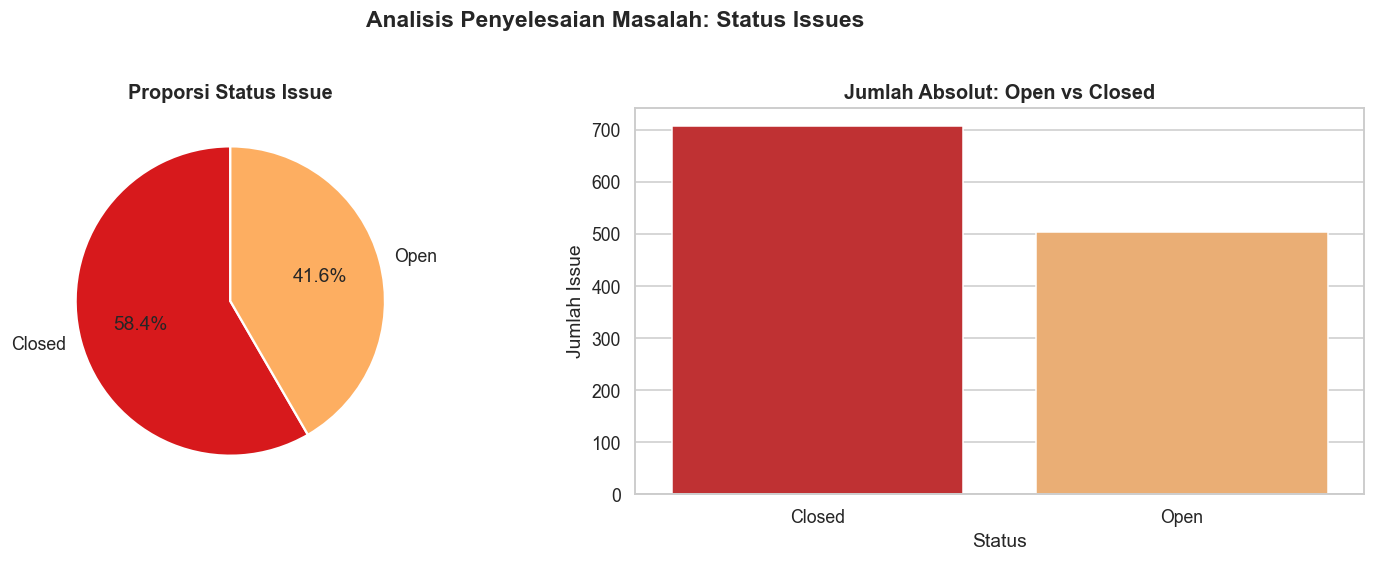

In [16]:
# Menghitung distribusi status pada dataset issues
issue_status_counts = df_issues["state"].value_counts()

print("Distribusi Status Issue:")
for status, count in issue_status_counts.items():
    persentase = (count / len(df_issues)) * 100
    print(f"- {status.capitalize()}: {count:,} ({persentase:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Pie Chart untuk Proporsi
axes[0].pie(issue_status_counts, labels=[s.capitalize() for s in issue_status_counts.index], 
            autopct='%1.1f%%', startangle=90, 
            colors=["#d7191c", "#fdae61"], wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title("Proporsi Status Issue", fontsize=13, fontweight="bold")

# Plot 2: Bar Plot untuk Jumlah Absolut
sns.barplot(x=[s.capitalize() for s in issue_status_counts.index], 
            y=issue_status_counts.values, ax=axes[1], palette=["#d7191c", "#fdae61"])
axes[1].set_title("Jumlah Absolut: Open vs Closed", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Jumlah Issue")
axes[1].set_xlabel("Status")

plt.suptitle("Analisis Penyelesaian Masalah: Status Issues", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

plt.show()

**Interpretasi Perbandingan Open vs Closed:** Dari Visualisasi diatas, kita dapat menyimpulkan bahwa issues pada repository kubernetes lebih banyak issues ter-"closed" sebesar 58.4% dari 1213 data.

### 3.4 Visualisasi Perbandingan Merged Vs Not Merged
Bagian ini membandingkan proporsi total Pull Request yang berhasil digabungkan (*Merged*) ke dalam *main branch* terhadap PR yang ditolak atau ditutup tanpa digabungkan (*Not Merged*).

Distribusi Status Pull Request:
- Merged: 2,860 (57.20%)
- Not Merged: 2,140 (42.80%)


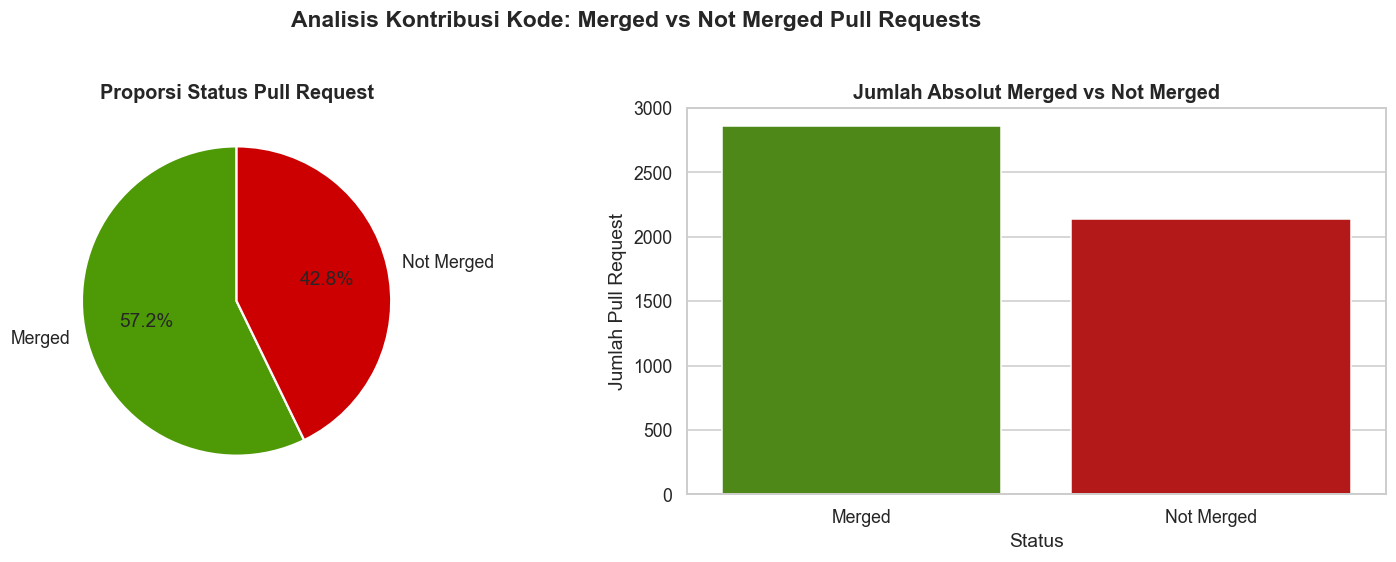

In [17]:
# Hitung distribusi status merge
merge_counts = df_prs["status_merge"].value_counts()
total_prs = len(df_prs)

print(f"Distribusi Status Pull Request:")
for status, count in merge_counts.items():
    persentase = (count / total_prs) * 100
    print(f"- {status}: {count:,} ({persentase:.2f}%)")

# Membuat plot perbandingan menggunakan Pie Chart dan Bar Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie Chart
axes[0].pie(merge_counts, labels=merge_counts.index, autopct='%1.1f%%', startangle=90, 
            colors=["#4e9a06", "#cc0000"], wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title("Proporsi Status Pull Request", fontsize=13, fontweight="bold")

# 2. Bar Plot
sns.barplot(x=merge_counts.index, y=merge_counts.values, ax=axes[1], palette=["#4e9a06", "#cc0000"])
axes[1].set_title("Jumlah Absolut Merged vs Not Merged", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Jumlah Pull Request")
axes[1].set_xlabel("Status")

plt.suptitle("Analisis Kontribusi Kode: Merged vs Not Merged Pull Requests", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

plt.show()

**Interpretasi Perbandingan Merged vs Not Merged:** Dari Visualisasi diatas, kita dapat menyimpulkan bahwa pull request pada repository kubernetes lebih cenderung ke "Merged" sebesar 57.2% dari 5000 data.

### 3.5 Visualisasi Distribusi Waktu Penyelesaian PR (Days to Close)
Bagian ini membandingkan waktu dari open PR ke PR closed (ditutup)

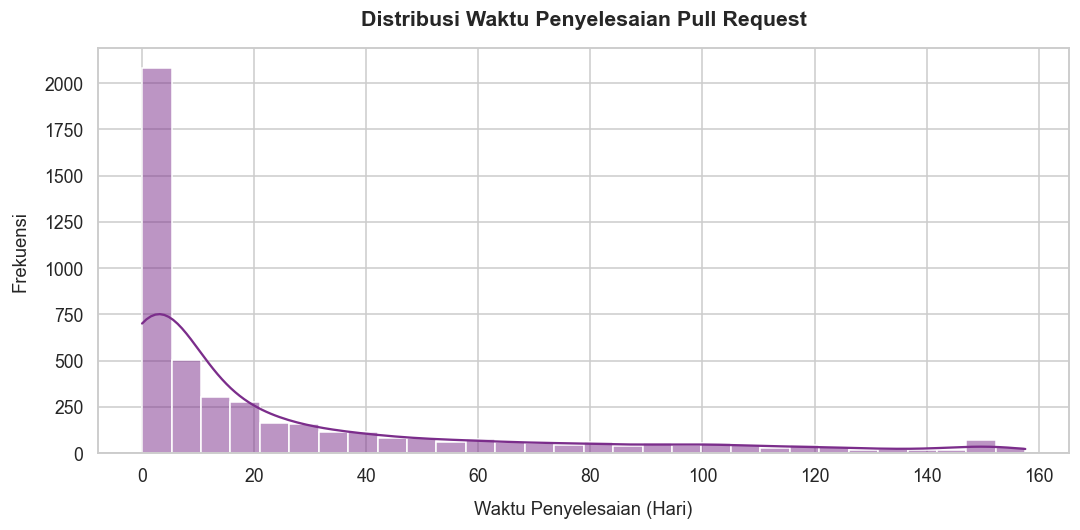

In [15]:
# 1. Menghitung durasi penyelesaian PR (days_to_close)
now = pd.Timestamp.now(tz="UTC")
end_time = df_prs["merged_at"].fillna(df_prs["closed_at"]).fillna(now)
df_prs["days_to_close"] = (end_time - df_prs["created_at"]).dt.total_seconds() / 86400
df_prs["days_to_close"] = df_prs["days_to_close"].clip(lower=0) # Mencegah nilai minus jika ada anomali waktu

# 2. Visualisasi Plot
plt.figure(figsize=(10, 5))

# Memfilter data: hanya durasi > 0 dan menghapus outlier ekstrem di persentil ke-95
batas_atas = df_prs["days_to_close"].quantile(0.95)
data_plot = df_prs[(df_prs["days_to_close"] > 0) & (df_prs["days_to_close"] <= batas_atas)]

sns.histplot(data=data_plot, x="days_to_close", bins=30, kde=True, color="#7b2d8b")
plt.title("Distribusi Waktu Penyelesaian Pull Request", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Waktu Penyelesaian (Hari)", fontsize=12, labelpad=10)
plt.ylabel("Frekuensi", fontsize=12, labelpad=10)
plt.tight_layout()

plt.show()

### 3.6 Visualisasi Distribusi Waktu Penutupan Issues (Days to Close)
Bagian ini membandingkan waktu dari open issues ke issues berhasil ditutup (Closed)

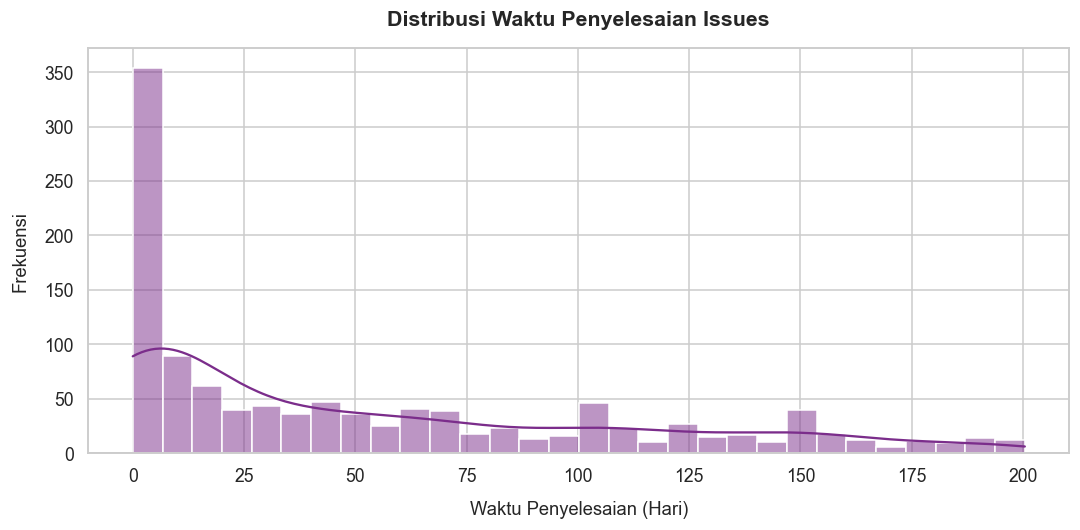

In [13]:
# 1. Menghitung durasi penyelesaian Issues (days_to_close)
now = pd.Timestamp.now(tz="UTC")
end_time = df_issues["closed_at"].fillna(now)
df_issues["days_to_close"] = (end_time - df_issues["created_at"]).dt.total_seconds() / 86400
df_issues["days_to_close"] = df_issues["days_to_close"].clip(lower=0) # Mencegah nilai minus jika ada anomali waktu

# 2. Visualisasi Plot
plt.figure(figsize=(10, 5))

# Memfilter data: hanya durasi > 0 dan menghapus outlier ekstrem di persentil ke-95
batas_atas = df_issues["days_to_close"].quantile(0.95)
data_plot = df_issues[(df_issues["days_to_close"] > 0) & (df_issues["days_to_close"] <= batas_atas)]

sns.histplot(data=data_plot, x="days_to_close", bins=30, kde=True, color="#7b2d8b")
plt.title("Distribusi Waktu Penyelesaian Issues", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Waktu Penyelesaian (Hari)", fontsize=12, labelpad=10)
plt.ylabel("Frekuensi", fontsize=12, labelpad=10)
plt.tight_layout()

plt.show()

---
## 4. Ekspor Dataset Bersih

Menyimpan subset fitur penting yang telah dibersihkan ke dalam folder `data/clean/` agar siap dikonsumsi langsung oleh anggota tim analisis berikutnya.

In [14]:
issues_export = df_issues[["id", "number", "state", "year_month", "created_at", "closed_at"]].copy()
prs_export = df_prs[["id", "number", "state", "is_merged", "status_merge", "year_month", "created_at", "closed_at", "merged_at"]].copy()

issues_export.to_csv(os.path.join(CLEAN_DIR, "dataset_issues_clean.csv"), index=False)
prs_export.to_csv(os.path.join(CLEAN_DIR, "dataset_prs_clean.csv"), index=False)

print(f"Data bersih Berhasil Disimpan:")
print(f"- {os.path.join(CLEAN_DIR, 'dataset_issues_clean.csv')} ({len(issues_export):,} baris)")
print(f"- {os.path.join(CLEAN_DIR, 'dataset_prs_clean.csv')} ({len(prs_export):,} baris)")

Data bersih Berhasil Disimpan:
- ..\data\clean\dataset_issues_clean.csv (1,213 baris)
- ..\data\clean\dataset_prs_clean.csv (5,000 baris)


---
## 5. Ringkasan Hasil Handoff

**Berkas Artefak yang Dihasilkan:**
- `data/clean/dataset_issues_clean.csv` — Data objek issues bersih.
- `data/clean/dataset_prs_clean.csv` — Data objek pull requests bersih.

Notebook siap digunakan dan seluruh dataset terisolasi secara aman tanpa risiko error skema kolom.